# Clean Taiko preprocessing: scanner manifest → CNN–LSTM tensors

Run this notebook on PACE after `scan_dataset.py` has written `manifest_strict.csv`. Each numbered section is one preprocessing stage.

## 0. Configure paths and experiment settings

In [48]:
from pathlib import Path
print(Path.cwd())

/Users/yunsukim/Documents/CS7643/Donderformer/playground


In [49]:
from pathlib import Path
import csv, json, subprocess
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = Path("input")
MANIFEST_PATH = Path("selected_15.csv")
OUTPUT_DIR = Path("processed_10")

SEED, N_SONGS = 42, 10
RUN_PIPELINE = True

SR, FRAME_MS, N_MELS = 44100, 23, 80
MEL_LO, MEL_HI, LOG_EPS = 27.5, 16000.0, 1e-16

CLASS_NAMES = ["none", "don", "ka", "DON", "KA", "drumroll", "denden"]

ONSET = {"1": 1, "2": 2, "3": 3, "A": 3, "4": 4, "B": 4}
LONG_START = {"5": 5, "6": 5, "7": 6, "9": 6}

FORBIDDEN_COMMANDS = {
    "BPMCHANGE", "DELAY", "BRANCHSTART", "BRANCHEND", "N", "E", "M"
}

ALLOWED_COMMANDS = {
    "MEASURE", "GOGOSTART", "GOGOEND",
    "SCROLL", "BARLINEON", "BARLINEOFF"
}

## 1. Load scanner-approved charts

Only `status == accepted` rows are eligible. Paths in the PACE manifest can be absolute or relative to `DATA_ROOT`.

In [50]:
def resolve_from_root(value):
    path = Path(value)
    return path if path.is_absolute() else DATA_ROOT / path


def load_accepted_rows():
    manifest_path = resolve_from_root(MANIFEST_PATH)

    if not manifest_path.is_file():
        raise FileNotFoundError(
            f"Selected-song manifest not found: {manifest_path.resolve()}"
        )

    with manifest_path.open(encoding="utf-8", newline="") as handle:
        rows = [
            row
            for row in csv.DictReader(handle)
            if row["status"] == "accepted"
        ]

    if len(rows) < N_SONGS:
        raise ValueError(
            f"Need {N_SONGS} accepted charts; found {len(rows)} in {manifest_path}."
        )

    return rows


accepted_rows = load_accepted_rows()
selected_rows = accepted_rows[:N_SONGS]

print(f"Accepted charts available: {len(accepted_rows)}")
print(f"Using first {len(selected_rows)} selected charts:")

for i, row in enumerate(selected_rows, 1):
    print(f"{i:2d}. {row['title']}")

Accepted charts available: 15
Using first 10 selected charts:
 1. Zankyou Sanka
 2. miracle shooting star
 3. thousand words
 4. March of the Toy Soldiers
 5. LOVE RAIN ～Koi no Ame～
 6. Zenryaku, Michi no Ue Yori
 7. Maigo no UFO
 8. Zenryoku Dive
 9. Wedding March
10. Usagi no Shippo


## 2. Select ten songs and make the song-level split

The split happens before feature normalization. No frames from a validation/test song may be used to fit normalization.

We need the validation set for model selection, so we keep a separate test set for an unbiased final comparison between the CNN-LSTM and Transformer.

In [51]:
selected_rows = accepted_rows[:N_SONGS]

for index, row in enumerate(selected_rows):
    row["song_id"] = f"{index:02d}_{Path(row['tja']).stem}"
    row["tja_path"] = resolve_from_root(row["tja"])
    row["audio_path"] = resolve_from_root(row["audio"])

ids = [row["song_id"] for row in selected_rows]

split = {
    "seed": SEED,
    "train": ids[:8],
    "validation": ids[8:9],
    "test": ids[9:10],
}

for row in selected_rows:
    if row["song_id"] in split["train"]:
        row["split"] = "train"
    elif row["song_id"] in split["validation"]:
        row["split"] = "validation"
    else:
        row["split"] = "test"

    print(f"{row['split']:10s} {row['song_id']} | {row['title']}")

train      00_Zankyou Sanka | Zankyou Sanka
train      01_miracle shooting star | miracle shooting star
train      02_thousand words | thousand words
train      03_March of the Toy Soldiers | March of the Toy Soldiers
train      04_LOVE RAIN Koi no Ame | LOVE RAIN ～Koi no Ame～
train      05_Zenryaku Michi no Ue Yori | Zenryaku, Michi no Ue Yori
train      06_Maigo no UFO | Maigo no UFO
train      07_Zenryoku Dive | Zenryoku Dive
validation 08_Wedding March | Wedding March
test       09_Usagi no Shippo | Usagi no Shippo


## 3. Decode audio and make chronological 23 ms chunks

In [52]:
def load_mono_audio(path):
    result = subprocess.run(
        ["ffmpeg", "-v", "error", "-i", str(path), "-ac", "1", "-ar", str(SR), "-f", "f32le", "-"],
        capture_output=True, check=True,
    )
    return np.frombuffer(result.stdout, dtype=np.float32)

def make_chunks(audio):
    duration_ms = len(audio) * 1000 / SR
    count = int(duration_ms // FRAME_MS)

    return [
        audio[
            int(k * FRAME_MS * SR / 1000):
            int((k + 1) * FRAME_MS * SR / 1000)
        ]
        for k in range(count)
    ]

## 4. Convert audio chunks to raw 80-band log-Mel features

In [53]:
_windows, _filterbanks = {}, {}
def hz_to_mel(freq): return 2595.0 * np.log10(1.0 + freq / 700.0)

def log_mel_features(audio_path):
    output = []
    for chunk in make_chunks(load_mono_audio(audio_path)):
        if len(chunk) < 4:
            output.append(np.zeros(N_MELS)); continue
        n = len(chunk)
        if n not in _windows:
            phase = 2 * np.pi * np.arange(n) / (n - 1)
            window = .44959 - .49364 * np.cos(phase) + .05677 * np.cos(2 * phase)
            _windows[n] = window * 2 / window.sum()
        y = np.roll(chunk * _windows[n], -(n // 2))
        if n % 2: y = np.delete(y, n // 2)
        power = np.abs(np.fft.rfft(y)) ** 2
        bins = len(power)
        if bins not in _filterbanks:
            edges = np.linspace(hz_to_mel(MEL_LO), hz_to_mel(MEL_HI), N_MELS + 2)
            bin_mels = hz_to_mel(np.arange(bins) * SR / 2 / (bins - 1))
            bank = np.zeros((N_MELS, bins))
            for i in range(N_MELS):
                left, center, right = edges[i:i+3]
                bank[i] = np.clip(np.minimum((bin_mels-left)/(center-left), (right-bin_mels)/(right-center)), 0, None)
                bank[i] /= bank[i].sum()
            _filterbanks[bins] = bank
        output.append(_filterbanks[bins] @ power)
    return np.log(np.asarray(output) + LOG_EPS).astype(np.float32)

## 5. TJA parser for accepted Oni charts

This is a second safety gate: it accepts `#MEASURE`, ignores visual commands, and raises an error for timing-changing or unknown commands.

This translates the TJA chart into timed musical events

In [54]:
def header_value(text, key):
    for raw in text.splitlines():
        line = raw.split("//", 1)[0].strip()
        if ":" in line:
            name, value = line.split(":", 1)
            if name.strip().upper() == key.upper():
                return value.strip()
    return None


def parse_events(path):
    text = path.read_text(encoding="utf-8-sig")

    bpm = float(header_value(text, "BPM"))
    offset = float(header_value(text, "OFFSET") or 0)

    course = None
    active = False
    body = []

    for raw in text.splitlines():
        line = raw.split("//", 1)[0].strip()

        if not line:
            continue

        if ":" in line:
            name, value = line.split(":", 1)

            if name.strip().upper() == "COURSE":
                course = value.strip().lower()
                continue

        upper = line.upper()

        if upper.startswith("#START"):
            active = course in {"oni", "3"}
            continue

        if upper.startswith("#END"):
            active = False
            continue

        if active:
            body.append(line)

    if not body:
        raise ValueError(f"{path}: no Oni body")

    time = -offset
    beats_per_measure = 4.0
    events = []
    opened = None
    measure_notes = []

    def process_measure():
        nonlocal time, opened, measure_notes

        if not measure_notes:
            time += beats_per_measure * 60.0 / bpm
            return

        measure_duration = beats_per_measure * 60.0 / bpm
        step = measure_duration / len(measure_notes)

        for note in measure_notes:
            if note == "8":
                if opened is None:
                    raise ValueError(f"{path}: unmatched 8")

                events.append((opened[0], opened[1], time))
                opened = None

            elif note in LONG_START:
                if opened is not None:
                    raise ValueError(f"{path}: nested long note")

                opened = (time, LONG_START[note])

            elif note in ONSET:
                if opened is not None:
                    raise ValueError(f"{path}: note inside long note")

                events.append((time, ONSET[note], None))

            elif note != "0":
                raise ValueError(f"{path}: unsupported note {note!r}")

            time += step

    for line in body:
        if line.startswith("#"):
            name, _, argument = line[1:].partition(" ")
            name = name.upper()
            argument = argument.strip()

            if name in FORBIDDEN_COMMANDS:
                raise ValueError(f"{path}: forbidden #{name}")

            if name == "MEASURE":
                num, den = argument.split("/")
                beats_per_measure = 4.0 * float(num) / float(den)

            elif name not in ALLOWED_COMMANDS:
                raise ValueError(f"{path}: unsupported #{name}")

            continue

        for char in line:
            if char == ",":
                process_measure()
                measure_notes = []

            elif not char.isspace():
                measure_notes.append(char.upper())

    if measure_notes:
        process_measure()

    if opened is not None:
        raise ValueError(f"{path}: unclosed long note")

    return events

## 6. Align events to the audio timeline and make one-hot labels

output will look like:
| 23 ms Frame | Audio           | Chart               |
|-------------|-----------------|---------------------|
| Frame 0     | 80 Mel features | `[1,0,0,0,0,0,0]`   |
| Frame 1     | 80 Mel features | `[1,0,0,0,0,0,0]`   |
| Frame 2     | 80 Mel features | `[0,1,0,0,0,0,0]` ← Don |
| Frame 3     | 80 Mel features | `[1,0,0,0,0,0,0]`   |
| Frame 4     | 80 Mel features | `[0,0,1,0,0,0,0]` ← Ka |

In [55]:
def events_to_labels(events, n_frames):
    labels = np.zeros(n_frames, dtype=np.int64)
    dropped = 0
    for start, cls, end in events:
        first = int(start * 1000 // FRAME_MS)
        if not 0 <= first < n_frames: dropped += 1; continue
        if end is None:
            if labels[first]: dropped += 1
            else: labels[first] = cls
        else:
            last = min(int(end * 1000 // FRAME_MS), n_frames - 1)
            span = labels[first:last + 1]
            span[span == 0] = cls
    if dropped: raise ValueError(f"{dropped} out-of-range or overlapping events")
    return np.eye(7, dtype=np.int32)[labels]

## 7. Extract and save raw artifacts per song

Raw features are saved before normalization, along with labels and metadata.

In [56]:
raw_data = {}

if RUN_PIPELINE:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    raw_root = OUTPUT_DIR / "raw"
    raw_root.mkdir(parents=True, exist_ok=True)

    for row in selected_rows:
        song_id = row["song_id"]

        print(f"Processing {song_id}...")

        features_raw = log_mel_features(row["audio_path"])
        events = parse_events(row["tja_path"])
        labels = events_to_labels(events, len(features_raw))

        if not np.isfinite(features_raw).all():
            raise ValueError(f"{song_id}: non-finite audio features")

        if not np.all(labels.sum(axis=1) == 1):
            raise ValueError(f"{song_id}: invalid one-hot labels")

        folder = raw_root / song_id
        folder.mkdir(parents=True, exist_ok=True)

        np.save(folder / "features_raw.npy", features_raw)
        np.save(folder / "labels.npy", labels)

        metadata = {
            **{
                k: str(v)
                for k, v in row.items()
                if k not in {"tja_path", "audio_path"}
            },
            "tja_path": str(row["tja_path"]),
            "audio_path": str(row["audio_path"]),
            "frames": len(features_raw),
            "events": len(events),
            "class_counts": labels.sum(axis=0).tolist()
        }

        (folder / "metadata.json").write_text(
            json.dumps(metadata, indent=2)
        )

        raw_data[song_id] = (features_raw, labels)

        print(
            f"  features={features_raw.shape}, "
            f"labels={labels.shape}, "
            f"events={len(events)}"
        )

    (OUTPUT_DIR / "split.json").write_text(
        json.dumps(split, indent=2)
    )

    print(f"Saved raw data for {len(raw_data)} songs.")

else:
    print("Set RUN_PIPELINE=True to extract raw artifacts.")

Processing 00_Zankyou Sanka...
  features=(3829, 80), labels=(3829, 7), events=438
Processing 01_miracle shooting star...
  features=(5422, 80), labels=(5422, 7), events=598
Processing 02_thousand words...
  features=(5930, 80), labels=(5930, 7), events=323
Processing 03_March of the Toy Soldiers...
  features=(4068, 80), labels=(4068, 7), events=493
Processing 04_LOVE RAIN Koi no Ame...
  features=(5314, 80), labels=(5314, 7), events=323
Processing 05_Zenryaku Michi no Ue Yori...
  features=(5121, 80), labels=(5121, 7), events=655
Processing 06_Maigo no UFO...
  features=(5641, 80), labels=(5641, 7), events=606
Processing 07_Zenryoku Dive...
  features=(5747, 80), labels=(5747, 7), events=548
Processing 08_Wedding March...
  features=(4918, 80), labels=(4918, 7), events=210
Processing 09_Usagi no Shippo...
  features=(6034, 80), labels=(6034, 7), events=524
Saved raw data for 10 songs.


## 8. Fit per-band normalization on training songs only

In [57]:
if RUN_PIPELINE:
    train_frames = np.concatenate(
        [raw_data[song_id][0] for song_id in split["train"]],
        axis=0
    )

    train_mean = train_frames.mean(axis=0)
    train_std = train_frames.std(axis=0)

    train_std = np.maximum(train_std, 1e-8)

    np.savez(
        OUTPUT_DIR / "normalization.npz",
        mean=train_mean,
        std=train_std
    )

    print("Train frames:", train_frames.shape)
    print("Mean:", train_mean.shape)
    print("Std:", train_std.shape)

else:
    print("Normalization waits for raw extraction.")

Train frames: (41072, 80)
Mean: (80,)
Std: (80,)


## 9. Normalize every split with frozen training statistics

In [58]:
normalized_data = {}
if RUN_PIPELINE:
    for song_id, (features_raw, labels) in raw_data.items():
        normalized_data[song_id] = ((features_raw - train_mean) / (train_std + 1e-8)).astype(np.float32), labels
    print("Normalized train, validation, and test songs with train statistics.")

Normalized train, validation, and test songs with train statistics.


## 10. Construct TaikoNation-compatible CNN–LSTM windows

Audio: 16 frames * 80 mel features = 1280 + Previous notes: 15 frames * 7 classes = 105 => 1385 (numbers in one window)

(4, 7) = 4 timesteps we predict and 7 possibe note classes at each timestep (i.e. Don, Ka ,,,)


In [59]:
def make_windows(features, labels):
    n = len(features)
    n_samples = n - 3

    audio_padded = np.vstack([
        np.zeros((15, N_MELS), dtype=np.float32),
        features
    ])

    label_padded = np.vstack([
        np.zeros((15, 7), dtype=np.float32),
        labels
    ])

    audio_indices = (
        np.arange(n_samples)[:, None]
        + np.arange(16)[None, :]
    )

    history_indices = (
        np.arange(n_samples)[:, None]
        + np.arange(15)[None, :]
    )

    target_indices = (
        np.arange(n_samples)[:, None]
        + 15
        + np.arange(4)[None, :]
    )

    audio_window = audio_padded[audio_indices]
    label_history = label_padded[history_indices]
    targets = label_padded[target_indices]

    X = np.concatenate([
        audio_window.reshape(n_samples, 16 * N_MELS),
        label_history.reshape(n_samples, 15 * 7)
    ], axis=1)

    Y = targets.astype(np.float32)

    return X.astype(np.float32), Y


if RUN_PIPELINE:
    window_root = OUTPUT_DIR / "normalized"
    window_root.mkdir(parents=True, exist_ok=True)

    for song_id, (features, labels) in normalized_data.items():
        X, Y = make_windows(features, labels)
        n_samples = len(features) - 3

        if X.shape != (n_samples, 1385):
            raise ValueError(
                f"{song_id}: unexpected X shape {X.shape}"
            )

        if Y.shape != (n_samples, 4, 7):
            raise ValueError(
                f"{song_id}: unexpected Y shape {Y.shape}"
            )

        if not np.all(Y.sum(axis=2) == 1):
            raise ValueError(
                f"{song_id}: invalid target one-hot labels"
            )

        folder = window_root / song_id
        folder.mkdir(parents=True, exist_ok=True)

        np.save(folder / "features.npy", features)
        np.savez_compressed(
            folder / "windows.npz",
            X=X,
            Y=Y
        )

        print(song_id, X.shape, Y.shape)

00_Zankyou Sanka (3826, 1385) (3826, 4, 7)
01_miracle shooting star (5419, 1385) (5419, 4, 7)
02_thousand words (5927, 1385) (5927, 4, 7)
03_March of the Toy Soldiers (4065, 1385) (4065, 4, 7)
04_LOVE RAIN Koi no Ame (5311, 1385) (5311, 4, 7)
05_Zenryaku Michi no Ue Yori (5118, 1385) (5118, 4, 7)
06_Maigo no UFO (5638, 1385) (5638, 4, 7)
07_Zenryoku Dive (5744, 1385) (5744, 4, 7)
08_Wedding March (4915, 1385) (4915, 4, 7)
09_Usagi no Shippo (6031, 1385) (6031, 4, 7)


## 11. Write a dataset report and check class balance

frame : how many 23ms pieces in that song
class: class distribution

In [60]:
if RUN_PIPELINE:
    report = []

    for row in selected_rows:
        song_id = row["song_id"]
        features, labels = normalized_data[song_id]

        report.append({
            "song_id": song_id,
            "title": row["title"],
            "split": row["split"],
            "frames": len(features),
            "class_counts": labels.sum(axis=0).astype(int).tolist()
        })

    (OUTPUT_DIR / "summary.json").write_text(
        json.dumps(report, indent=2)
    )

    for item in report:
        print(
            item["split"],
            item["song_id"],
            "frames=", item["frames"],
            "classes=", item["class_counts"]
        )

train 00_Zankyou Sanka frames= 3829 classes= [3340, 249, 150, 33, 4, 53, 0]
train 01_miracle shooting star frames= 5422 classes= [4560, 346, 213, 19, 15, 173, 96]
train 02_thousand words frames= 5930 classes= [4890, 142, 163, 10, 0, 725, 0]
train 03_March of the Toy Soldiers frames= 4068 classes= [3575, 257, 225, 4, 7, 0, 0]
train 04_LOVE RAIN Koi no Ame frames= 5314 classes= [4777, 201, 106, 10, 4, 0, 216]
train 05_Zenryaku Michi no Ue Yori frames= 5121 classes= [4261, 358, 280, 8, 4, 52, 158]
train 06_Maigo no UFO frames= 5641 classes= [4986, 301, 274, 28, 0, 21, 31]
train 07_Zenryoku Dive frames= 5747 classes= [4496, 258, 236, 19, 22, 507, 209]
validation 08_Wedding March frames= 4918 classes= [4494, 142, 51, 12, 1, 106, 112]
test 09_Usagi no Shippo frames= 6034 classes= [5330, 194, 304, 11, 12, 183, 0]


## 12. Optional visual alignment check

Run after extraction to inspect whether note onsets occur near visible changes in the log-Mel features.

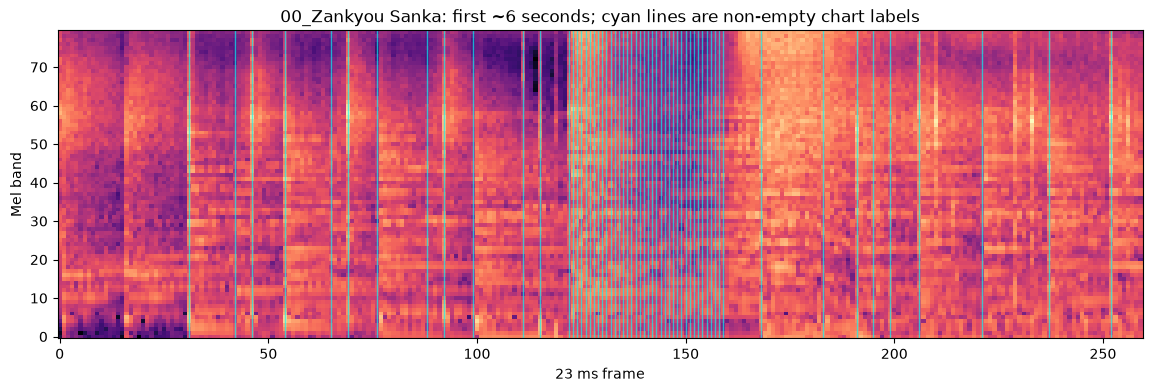

In [61]:
if RUN_PIPELINE:
    song_id = selected_rows[0]["song_id"]
    features, labels = normalized_data[song_id]
    plt.figure(figsize=(14, 4))
    plt.imshow(features[:260].T, origin="lower", aspect="auto", cmap="magma")
    for frame, cls in enumerate(labels[:260].argmax(axis=1)):
        if cls: plt.axvline(frame, color="cyan", alpha=.65, linewidth=1)
    plt.title(f"{song_id}: first ~6 seconds; cyan lines are non-empty chart labels")
    plt.xlabel("23 ms frame"); plt.ylabel("Mel band"); plt.show()
else:
    print("Visualization waits for successful extraction.")